<a href="https://colab.research.google.com/github/poojithasharini/hpc_project/blob/main/HPC_Project_4011.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('/content/Travel_Times - Bogota.csv')
print(df.head())
print(df.info())

   Origin Movement ID       Origin Display Name  \
0                 183  SANTA INES, 003107 (183)   
1                 183  SANTA INES, 003107 (183)   
2                 183  SANTA INES, 003107 (183)   
3                 183  SANTA INES, 003107 (183)   
4                 183  SANTA INES, 003107 (183)   

                                     Origin Geometry  Destination Movement ID  \
0  [[-74.081141,4.595074],[-74.081746,4.595449],[...                        4   
1  [[-74.081141,4.595074],[-74.081746,4.595449],[...                        6   
2  [[-74.081141,4.595074],[-74.081746,4.595449],[...                        8   
3  [[-74.081141,4.595074],[-74.081746,4.595449],[...                        9   
4  [[-74.081141,4.595074],[-74.081746,4.595449],[...                       11   

     Destination Display Name  \
0     PALO BLANCO, 005501 (4)   
1   BANCO CENTRAL, 007208 (6)   
2   LA ESTANZUELA, 004104 (8)   
3      LAS NIEVES, 003102 (9)   
4  BARCELONA SUR, 001424 (11)   

       

In [ ]:
import pandas as pd
import time

# Load dataset
df = pd.read_csv('/content/Travel_Times - Washington DC.csv')
df = pd.concat([df]*50)

# Select a numeric column (change if needed)
col = df.select_dtypes(include=['float64', 'int64']).columns[0]

start = time.time()

total = 0
for val in df[col]:
    for _ in range(500):   # heavy computation added
        total += val * 2

end = time.time()

serial_time = end - start

print("Serial Result:", total)
print("Serial Time:", serial_time)

Serial Result: 5115000000
Serial Time: 1.4708387851715088


In [ ]:
import pandas as pd
import time
import numpy as np
from multiprocessing import Pool, cpu_count

# Load dataset
df = pd.read_csv('/content/Travel_Times - Washington DC.csv')
df = pd.concat([df]*50)

col = df.select_dtypes(include=['float64', 'int64']).columns[0]

# Function
def process_chunk(chunk):
    total = 0
    for val in chunk:
        for _ in range(500):   # same heavy work
            total += val * 2
    return total

# Prepare data
data = df[col].values

num_processes = cpu_count()
chunks = np.array_split(data, num_processes)

start = time.time()

with Pool(num_processes) as p:
    results = p.map(process_chunk, chunks)

parallel_total = sum(results)

end = time.time()

parallel_time = end - start

print("Parallel Result:", parallel_total)
print("Parallel Time:", parallel_time)

Parallel Result: 5115000000
Parallel Time: 1.1352806091308594


In [ ]:
print("\n--- Comparison ---")
print("Serial Time:", serial_time)
print("Parallel Time:", parallel_time)

speedup = serial_time / parallel_time if parallel_time > 0 else 0
print("Speedup:", speedup)


--- Comparison ---
Serial Time: 1.4708387851715088
Parallel Time: 1.1352806091308594
Speedup: 1.2955728947907812


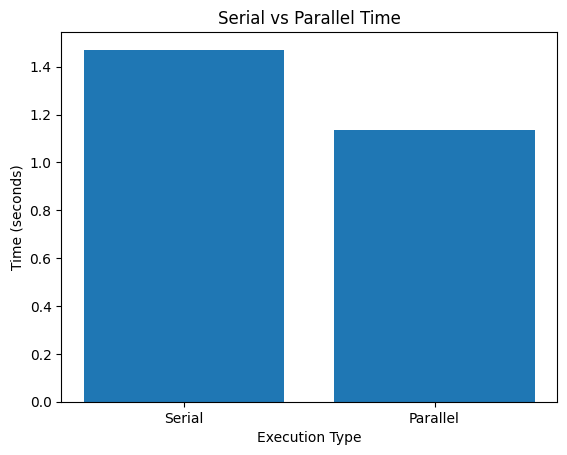

In [ ]:
import matplotlib.pyplot as plt

labels = ['Serial', 'Parallel']
times = [serial_time, parallel_time]

plt.figure()
plt.bar(labels, times)

plt.xlabel("Execution Type")
plt.ylabel("Time (seconds)")
plt.title("Serial vs Parallel Time")

plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Confusion Matrix:
 [[110]]


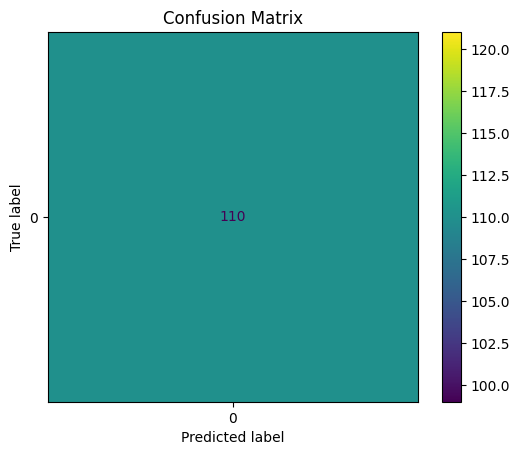

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/content/Travel_Times - Washington DC.csv')

# Select numeric column
col = df.select_dtypes(include=['float64', 'int64']).columns[0]

# Create labels (classification)
threshold = df[col].mean()

df['Traffic'] = df[col].apply(lambda x: 1 if x > threshold else 0)

# Features (X) and Target (y)
X = df[[col]]
y = df['Traffic']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

Value counts for y_test (from previous split):
Traffic
0    60
1    50
Name: count, dtype: int64

Value counts for y_pred (from previous split):
0    60
1    50
Name: count, dtype: int64

Confusion Matrix (with stratified split):
 [[52  0]
 [ 0 58]]


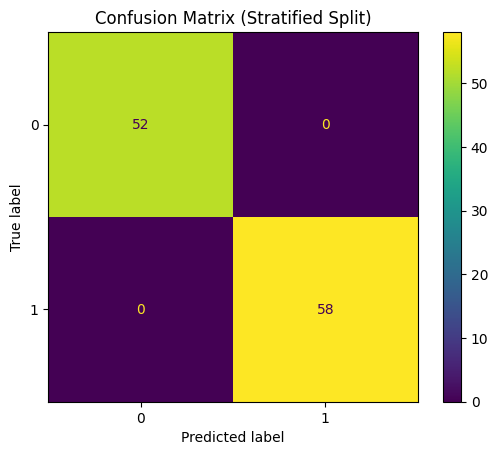


Value counts for y_test_strat (after stratified split):
Traffic
1    58
0    52
Name: count, dtype: int64

Value counts for y_pred_strat (after stratified split):
1    58
0    52
Name: count, dtype: int64


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

# Load dataset and create initial X, y (from jNt-2Az2rODr)
df = pd.read_csv('/content/Travel_Times - Washington DC.csv')
# Change the column to one with more variance to create a meaningful target variable
col = 'Mean Travel Time (Seconds)'

threshold = df[col].mean()
df['Traffic'] = df[col].apply(lambda x: 1 if x > threshold else 0)
X = df[[col]]
y = df['Traffic']

# Perform the initial non-stratified split (from jNt-2Az2rODr)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train the initial model and get predictions (from jNt-2Az2rODr)
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# The previous confusion matrix showed a warning about a single label.
# Let's inspect the labels in y_test and y_pred from the previous run to understand why.
print("Value counts for y_test (from previous split):")
print(y_test.value_counts())

print("\nValue counts for y_pred (from previous split):")
print(pd.Series(y_pred).value_counts())

# As seen from the value counts, if either y_test or y_pred (or both) contain only a single class,
# the confusion matrix will be problematic. This usually happens if the
# dataset is imbalanced and train_test_split is not stratified.

# To get a more representative confusion matrix, we can use `stratify`
# in train_test_split to ensure the same proportion of class labels
# in both training and test sets as in the input dataset (y).

# Re-split the data using stratify to maintain class distribution
X_train_strat, X_test_strat, y_train_strat, y_test_strat = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Re-train the model with the stratified split
model_strat = DecisionTreeClassifier(random_state=42)
model_strat.fit(X_train_strat, y_train_strat)

# Make predictions on the stratified test set
y_pred_strat = model_strat.predict(X_test_strat)

# Calculate the new confusion matrix
cm_strat = confusion_matrix(y_test_strat, y_pred_strat)

print("\nConfusion Matrix (with stratified split):\n", cm_strat)

# Plot the new confusion matrix
disp_strat = ConfusionMatrixDisplay(confusion_matrix=cm_strat)
disp_strat.plot()
plt.title("Confusion Matrix (Stratified Split)")
plt.show()

# Print value counts for stratified test set to confirm the balance
print("\nValue counts for y_test_strat (after stratified split):")
print(y_test_strat.value_counts())
print("\nValue counts for y_pred_strat (after stratified split):")
print(pd.Series(y_pred_strat).value_counts())

In [ ]:
shortest_travel_time = df['Range - Lower Bound Travel Time (Seconds)'].min()
longest_travel_time = df['Range - Upper Bound Travel Time (Seconds)'].max()

print(f"Overall shortest travel time observed: {shortest_travel_time} seconds")
print(f"Overall longest travel time observed: {longest_travel_time} seconds")

Overall shortest travel time observed: 83 seconds
Overall longest travel time observed: 3303 seconds


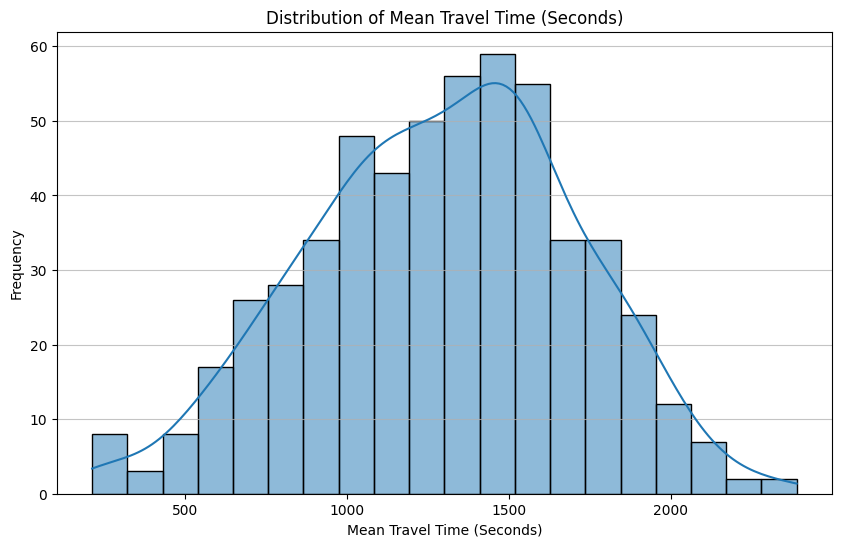

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Mean Travel Time (Seconds)'], bins=20, kde=True)
plt.title('Distribution of Mean Travel Time (Seconds)')
plt.xlabel('Mean Travel Time (Seconds)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

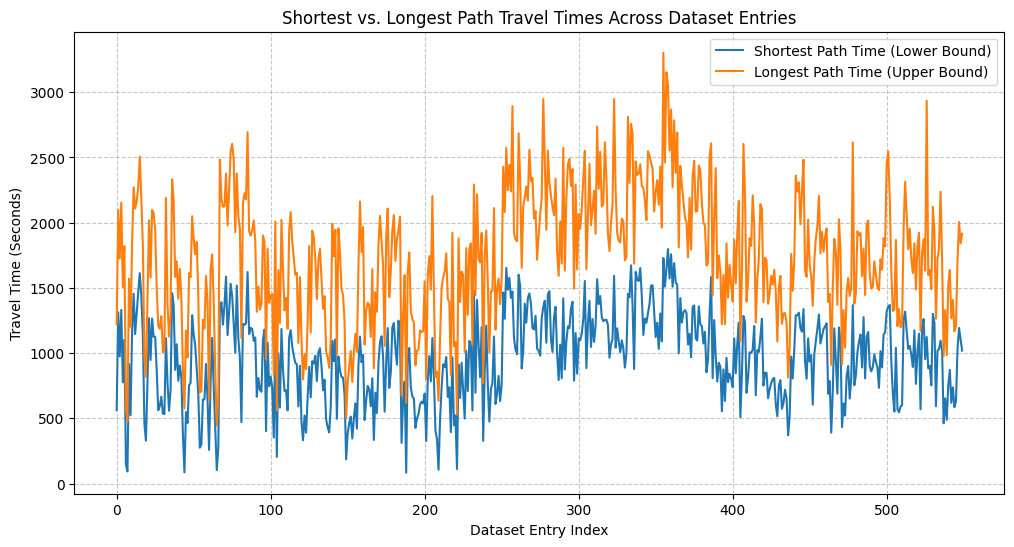

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(data=df['Range - Lower Bound Travel Time (Seconds)'], label='Shortest Path Time (Lower Bound)')
sns.lineplot(data=df['Range - Upper Bound Travel Time (Seconds)'], label='Longest Path Time (Upper Bound)')

plt.title('Shortest vs. Longest Path Travel Times Across Dataset Entries')
plt.xlabel('Dataset Entry Index')
plt.ylabel('Travel Time (Seconds)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()